In [1]:
import numpy as np

import scarf
from scarf.plotting import CategoricalScale, CellField

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
cell_type_by_cluster = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "T cells",
    "8": "T cells",
    "9": "B cells",
    "10": "pDC-like cells",
}
cell_type_order = (
    "CD14 monocytes",
    "monocytes",
    "B cells",
    "T cells",
    "NK cells",
    "pDC-like cells",
)

cluster_values = np.asarray(run.cells.fetch("clusters"))
observed_clusters = {str(value) for value in np.unique(cluster_values)}
assert observed_clusters == set(cell_type_by_cluster)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_types = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_types[analysis_cells] = [
    cell_type_by_cluster[str(value)] for value in cluster_values
]
ds.cells.insert("pbmc_cell_type", cell_types, overwrite=True)
ds.cells.insert("rna_analysis_cells", analysis_cells, overwrite=True)

In [3]:
broad_markers = ds.get_markers(
    marker=run["markers"],
    min_score=-1,
    min_frac_exp=-1,
)
broad_best = (
    broad_markers[broad_markers["feature_name"].isin(
        ["CD14", "CDKN1C", "TCF7L2", "MS4A1", "CD3D", "NKG7",
         "IL3RA", "IGHD", "IGHA1"]
    )]
    .sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")["group_id"]
    .astype(str)
    .to_dict()
)
assert broad_best["CD14"] == "1"
assert broad_best["CDKN1C"] == "2"
assert broad_best["TCF7L2"] == "2"
assert broad_best["MS4A1"] in {"3", "9"}
assert broad_best["CD3D"] in {"4", "5", "7", "8"}
assert broad_best["NKG7"] == "6"
assert broad_best["IL3RA"] == "10"
assert broad_best["IGHD"] == "9"
assert broad_best["IGHA1"] == "3"
broad_best

{'CD14': '1',
 'IGHA1': '3',
 'IL3RA': '10',
 'IGHD': '9',
 'TCF7L2': '2',
 'CDKN1C': '2',
 'NKG7': '6',
 'MS4A1': '3',
 'CD3D': '7'}

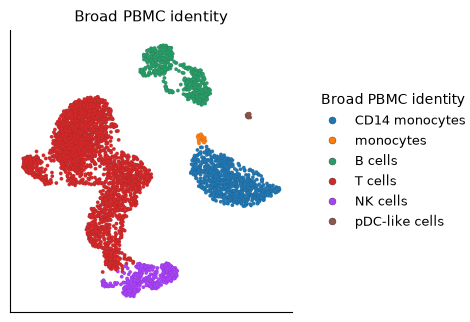

In [4]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=CellField(
        "pbmc_cell_type",
        kind="categorical",
        label="Broad PBMC identity",
    ),
    categorical_scale=CategoricalScale(order=cell_type_order),
    legend_loc="right",
)

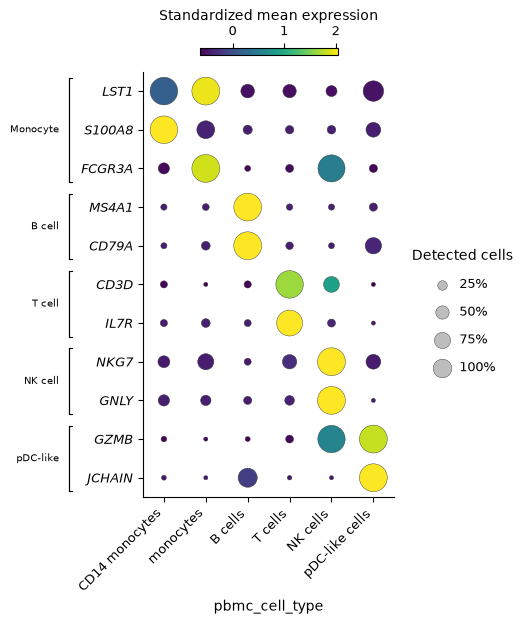

In [5]:
marker_panel = {
    "Monocyte": ["LST1", "S100A8", "FCGR3A"],
    "B cell": ["MS4A1", "CD79A"],
    "T cell": ["CD3D", "IL7R"],
    "NK cell": ["NKG7", "GNLY"],
    "pDC-like": ["GZMB", "JCHAIN"],
}
ds.plots.dotplot(
    features=marker_panel,
    group_by="pbmc_cell_type",
    cell_key="rna_analysis_cells",
    group_order=cell_type_order,
    standardize="feature",
    italicize_features=True,
)